In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
df = pd.read_csv('/content/part_3_customer_churn_prediction.csv')

df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,TEL00001,Male,0,Yes,No,42,Yes,Yes,Fiber optic,Yes,...,No,No,No,Yes,One year,Yes,Electronic check,102.95,4306.99,No
1,TEL00002,Female,0,No,Yes,55,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,Yes,One year,No,Credit card,120.39,6588.83,No
2,TEL00003,Female,0,Yes,Yes,0,Yes,No,DSL,No,...,Yes,No,No,Yes,Two year,No,Mailed check,74.42,0.00,Yes
3,TEL00004,Female,0,No,Yes,16,Yes,Yes,DSL,No,...,Yes,Yes,No,Yes,Month-to-month,No,Mailed check,83.24,1324.06,No
4,TEL00005,Male,0,Yes,No,6,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,25.44,123.68,Yes


# Customer Churn Prediction

In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1800 non-null   object 
 1   Gender            1800 non-null   object 
 2   SeniorCitizen     1800 non-null   int64  
 3   Partner           1800 non-null   object 
 4   Dependents        1800 non-null   object 
 5   Tenure            1800 non-null   int64  
 6   PhoneService      1800 non-null   object 
 7   MultipleLines     1800 non-null   object 
 8   InternetService   1800 non-null   object 
 9   OnlineSecurity    1800 non-null   object 
 10  OnlineBackup      1800 non-null   object 
 11  DeviceProtection  1800 non-null   object 
 12  TechSupport       1800 non-null   object 
 13  StreamingTV       1800 non-null   object 
 14  StreamingMovies   1800 non-null   object 
 15  Contract          1800 non-null   object 
 16  PaperlessBilling  1800 non-null   object 


,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,1800.000000,1800.000000,1800.000000,1769.000000
mean,0.162778,22.603889,74.462250,1699.169503
std,0.369265,20.165802,31.532909,1780.084580
min,0.000000,0.000000,18.000000,0.000000
25%,0.000000,6.000000,53.150000,383.650000
50%,0.000000,16.000000,79.665000,1077.400000
75%,0.000000,33.000000,98.567500,2436.040000
max,1.000000,72.000000,139.460000,10040.700000


The dataset contains customer information used to predict whether a customer is likely to leave the business.

In [8]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df=df.dropna()

In [10]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [11]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [14]:
y_pred = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7175141242937854


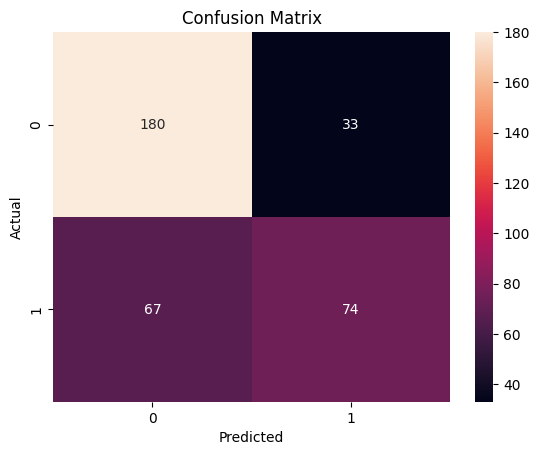

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.85      0.78       213
           1       0.69      0.52      0.60       141

    accuracy                           0.72       354
   macro avg       0.71      0.68      0.69       354
weighted avg       0.71      0.72      0.71       354



## Business Insights

- Customer churn prediction helps identify customers likely to leave.
- Business can improve retention strategies using predictive analytics.
- Early identification of churn reduces customer loss.

## Final Recommendations

- Offer personalized retention campaigns.
- Improves customer engagement strategies.
- Monitor customer behaviour continuosly.
- Use churn prediction models regularly for business decisions.  